# Notebook to analyze marine data

In [1]:
import pathlib

import numpy as np
import pandas as pd

In [2]:
feature_file = pathlib.Path("../data/interim/features/marine/kofam.tsv")
feature_data = pd.read_csv(feature_file, sep="\t", index_col=0)
feature_data

,K00003,K00004,K00005,K00006,K00007,K00009,K00010,K00012,K00013,K00014,...,K26057,K26058,K26059,K26060,K26061,K26063,K26064,K26065,K26138,K26139
genomeID,,,,,,,,,,,,,,,,,,,,,
12B01,0,0,0,0,0,1,0,1,1,1,...,0,0,0,0,0,1,0,0,0,0
13B01,0,0,0,0,0,1,0,1,1,1,...,0,0,0,0,0,1,0,0,0,0
3C02,0,0,0,0,0,1,0,1,1,1,...,0,0,0,0,0,1,0,0,0,0
3D04,0,1,0,0,0,0,0,1,1,1,...,0,0,1,1,0,1,0,0,0,0
3F01,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
I2R16,0,0,0,0,0,0,0,1,1,1,...,0,0,1,1,0,1,0,0,0,0
I3M07,0,0,0,0,0,1,0,1,1,1,...,0,0,0,0,0,1,0,0,0,0
I3M17,0,0,0,0,0,0,0,1,1,0,...,0,0,1,1,0,0,0,0,0,0


In [3]:
phenotype_file = pathlib.Path("../data/raw/phenotypes/marine_phenotypes.tsv")
phenotype_data = pd.read_csv(phenotype_file, sep="\t", index_col=0)
phenotype_data

,glucuronate,gluconate,galacturonate,gluconate lactone,glucuronate lactone,glucosamine,glcnac,mannosamine,galnac,galactosamine,...,porphyran,propanol,pullulan,sorbitol,starch,thymidine,thymine,ulvan,uridine,xylan
genomeID,,,,,,,,,,,,,,,,,,,,,
12B01,0,1,0,1,0,1,1,0,0,0,...,0,0,1,0,1,1,0,0,1,0
13B01,0,1,0,1,0,1,1,0,0,0,...,0,0,1,0,1,1,0,0,1,0
3C02,0,1,0,1,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
3D04,0,1,1,1,0,0,0,0,0,0,...,1,0,1,0,1,1,0,0,1,0
3F01,0,0,0,1,0,1,1,0,1,0,...,0,1,1,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
I2R16,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I3M07,0,1,0,1,0,1,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0
I3M17,0,0,0,0,0,1,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0


## Train-test using sklearn RandomForestClassifier

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [5]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, matthews_corrcoef

In [6]:
from tqdm import tqdm

In [7]:
phenotype_names = list(phenotype_data.columns)

In [8]:
score_data = []
pbar = tqdm(total=len(phenotype_names))
for i, phenotype_name in enumerate(phenotype_names):
    pbar.set_description(f"Phenotype {i + 1}/{len(phenotype_names)}: {phenotype_name}")
    y = phenotype_data[phenotype_name].dropna().astype(int)
    X = feature_data.loc[y.index, :].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    clf = RandomForestClassifier(n_estimators=1_000, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores = {
        "phenotype": phenotype_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy_score": balanced_accuracy_score(y_test, y_pred),
        "mcc": matthews_corrcoef(y_test, y_pred),
    }
    score_data.append(scores)
    pbar.update(1)

Phenotype 100/100: xylan: 100%|██████████| 100/100 [01:31<00:00,  1.12it/s]           

## Visualizing Marine Data

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
score_df = pd.DataFrame(score_data)
score_df.index = pd.Index(phenotype_names)
score_df.index.name = "Phenotype"
score_df.reset_index(inplace=True)
score_df

,Phenotype,accuracy,balanced_accuracy_score,mcc
0,glucuronate,0.942857,0.833333,0.789719
1,gluconate,0.971429,0.954545,0.934199
2,galacturonate,0.914286,0.750000,0.673146
3,gluconate lactone,0.800000,0.748188,0.539086
4,glucuronate lactone,0.857143,0.642857,0.492366
...,...,...,...,...
95,thymidine,0.885714,0.793981,0.655092
96,thymine,0.942857,0.817708,0.635417
97,ulvan,0.914286,0.625000,0.477432
98,uridine,0.828571,0.776515,0.587412


/home/g8k/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/g8k/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/g8k/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: xlabel='metric', ylabel='score'>

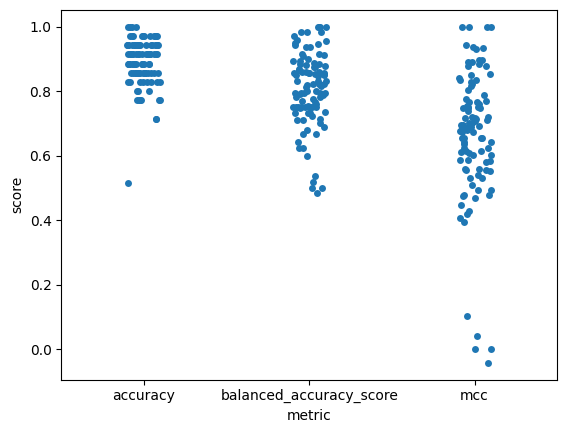

In [19]:
plot_data = score_df.melt(id_vars=["Phenotype"], var_name="metric", value_name="score")
sns.stripplot(data=plot_data, x="metric", y="score")